In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from sysmex_task1_dataset import SysmexTask1Dataset, PROFILE_SCALE
from torch.utils import data

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd

import matplotlib
import matplotlib_inline
matplotlib.rc('pdf', fonttype=42)
matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")

In [5]:
dataset = SysmexTask1Dataset(
    csv_path="../data/task1_dataset_split.csv.zip",
    preprocessed_root="../data/task1_processed/",
    profile_scale = (1,1,1),
    brightfield_postfix = "_brightfield_crop_masked_normalized_avebg_pad128.png",
)

In [89]:
def visualize_item(item,index=None):
    image = item["image"].squeeze().numpy()
    profiles = item["profile"].numpy()
    metadata = item["metadata"]

    figure, axes = plt.subplots(1, 4, figsize=(10, 2.5))

    # Brightfield image
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Brightfield image")
    axes[0].set_xlabel(f"width={image.shape[1]}")
    axes[0].set_ylabel(f"height={image.shape[0]}")

    # Profiles
    names = ("SSC profile", "CD45 profile", "Mask profile")
    colors = ("darkslateblue", "crimson", "forestgreen")

    for axis, profile, name, color in zip(axes[1:], profiles, names, colors):
        axis.plot(profile, color=color)
        axis.set_title(name)
        axis.set_xlabel("Pixel index")
        axis.set_ylabel("Value")

    # Title
    cell_id = metadata['cell_id']
    title = f"Dataset item {index}" if index is not None else "Dataset item"
    title += f" | cell ID: {cell_id}"

    figure.suptitle(title, fontsize=12)
    figure.tight_layout()
    plt.show()

In [20]:
split_indices = {"train": [], "val": [], "test": []}
for index, row in enumerate(dataset.rows):
    split = row["split"].strip().lower()
    if split not in split_indices:
        raise ValueError(
            f"unexpected split {row[args.split_column]!r}; expected train, val, or test"
        )
    split_indices[split].append(index)

train_dataset = data.Subset(dataset, split_indices["train"])
val_dataset = data.Subset(dataset, split_indices["val"])
test_dataset = data.Subset(dataset, split_indices["test"])

index = 100
item = test_dataset[index]



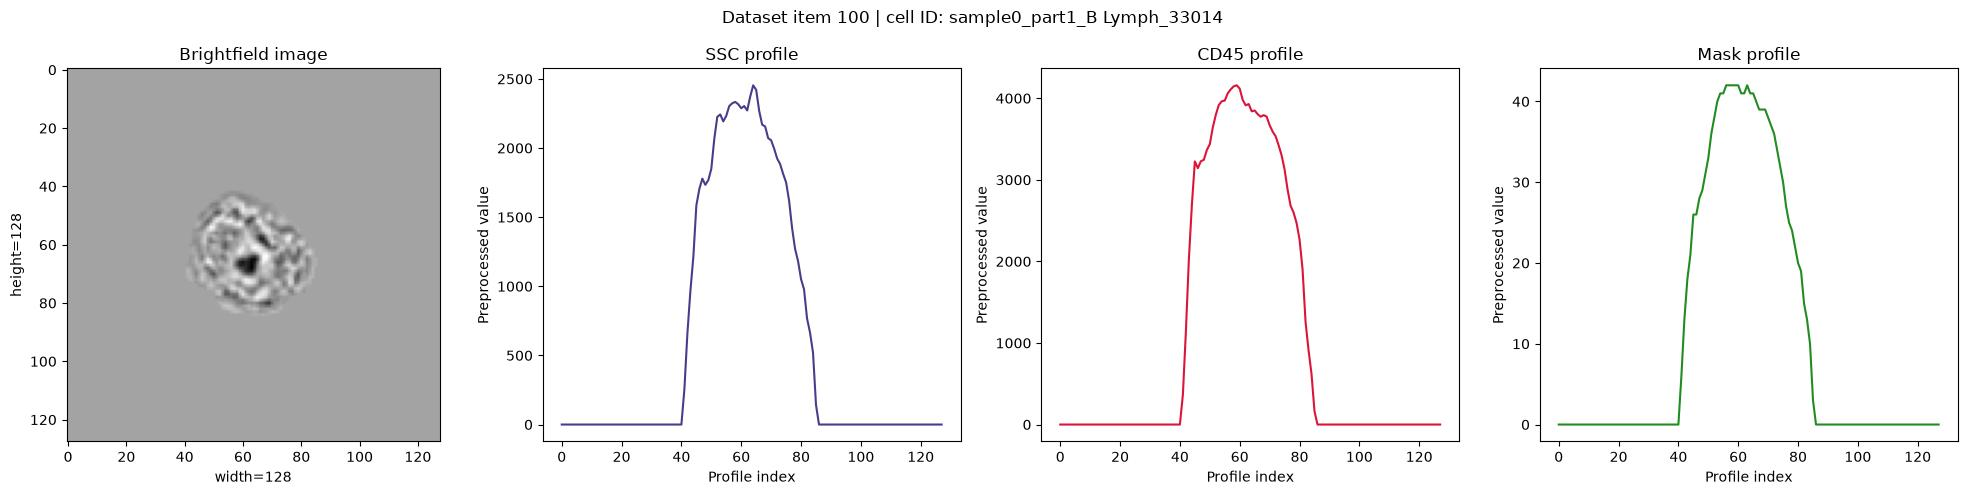

In [ ]:
visualize_item(item)

In [24]:
df = pd.DataFrame(dataset.rows)

,cell_id,cell_type,bright_field_path,dark_field_path,cd45_field_path,mask_path,width,height,sample_idx,sample_group,split
40,sample0_part1_B Lymph_14408,B Lymph,../data/Task1_dataset/sample0_part1/B Lymph/Or...,../data/Task1_dataset/sample0_part1/B Lymph/Or...,../data/Task1_dataset/sample0_part1/B Lymph/Or...,../data/Task1_dataset/sample0_part1/B Lymph/Ma...,50,61,sample0,sample0_part1,test
46854,sample0_part3_Eo_5626,Eo,../data/Task1_dataset/sample0_part3/Eo/Origina...,../data/Task1_dataset/sample0_part3/Eo/Origina...,../data/Task1_dataset/sample0_part3/Eo/Origina...,../data/Task1_dataset/sample0_part3/Eo/Masks/s...,57,69,sample0,sample0_part3,test
47469,sample0_part3_Mono_45148,Mono,../data/Task1_dataset/sample0_part3/Mono/Origi...,../data/Task1_dataset/sample0_part3/Mono/Origi...,../data/Task1_dataset/sample0_part3/Mono/Origi...,../data/Task1_dataset/sample0_part3/Mono/Masks...,56,69,sample0,sample0_part3,test
13236,sample0_part1_Neut_39212,Neut,../data/Task1_dataset/sample0_part1/Neut/Origi...,../data/Task1_dataset/sample0_part1/Neut/Origi...,../data/Task1_dataset/sample0_part1/Neut/Origi...,../data/Task1_dataset/sample0_part1/Neut/Masks...,64,78,sample0,sample0_part1,test
21149,sample0_part1_T Lymph_34817,T Lymph,../data/Task1_dataset/sample0_part1/T Lymph/Or...,../data/Task1_dataset/sample0_part1/T Lymph/Or...,../data/Task1_dataset/sample0_part1/T Lymph/Or...,../data/Task1_dataset/sample0_part1/T Lymph/Ma...,58,69,sample0,sample0_part1,test


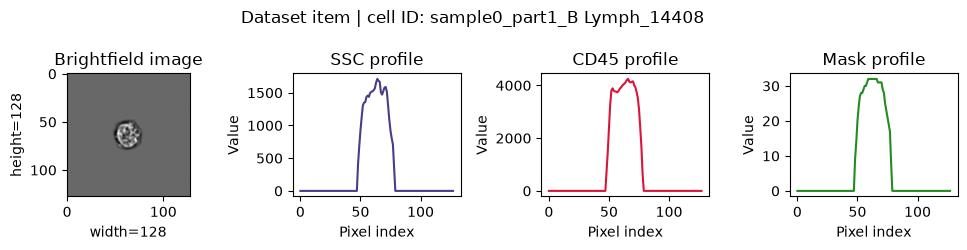

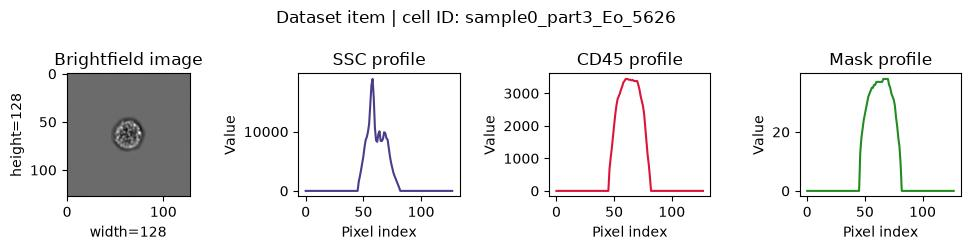

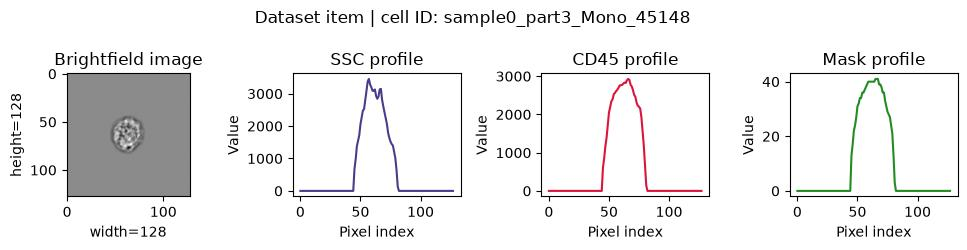

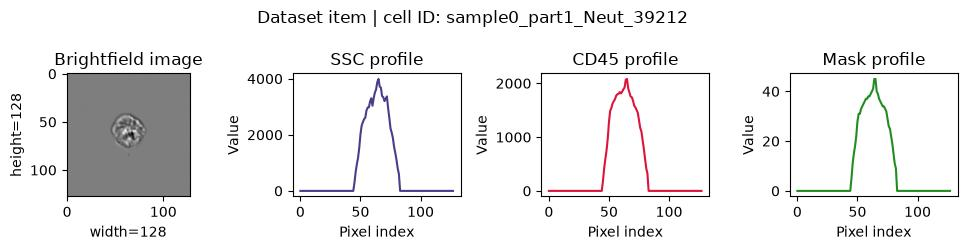

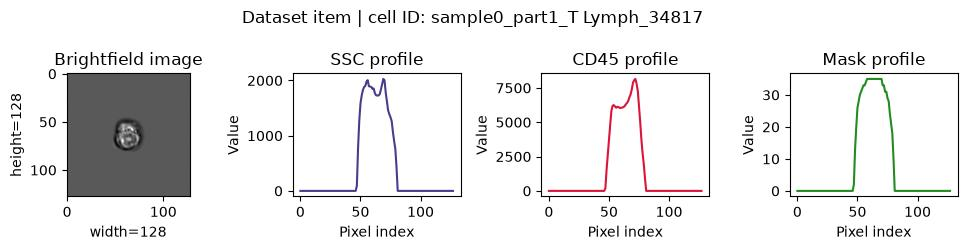

In [90]:
k = 1
sampled = (
    df.query("split == 'test'")
      .groupby("cell_type", group_keys=False)
      .sample(n=k, random_state=104)
)
display(sampled)
for idx,row in sampled.iterrows():
    visualize_item(dataset[idx])

In [83]:
sampled['cell_id'].tolist()

['sample0_part1_B Lymph_14408',
 'sample0_part3_Eo_5626',
 'sample0_part3_Mono_45148',
 'sample0_part1_Neut_39212',
 'sample0_part1_T Lymph_34817']